In [1]:
!pip install kagglehub --upgrade

In [2]:
import kagglehub

In [3]:
kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

100%|██████████| 639M/639M [00:09<00:00, 74.4MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1'

In [4]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data_path = Path('/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1')

song_data_path = data_path / 'Music Info.csv'
users_data_path = data_path / 'User Listening History.csv'

In [6]:
# songs data

df_songs = pd.read_csv(song_data_path,usecols = ["track_id","name","artist","spotify_preview_url"])
df_songs.head()

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...


In [7]:
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   track_id             50683 non-null  object
 1   name                 50683 non-null  object
 2   artist               50683 non-null  object
 3   spotify_preview_url  50683 non-null  object
dtypes: object(4)
memory usage: 1.5+ MB


In [8]:
!pip install dask[dataframe]

In [9]:
import dask.dataframe as dd

# load the dataset
df_users = dd.read_csv(users_data_path)
df_users.head()


,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [10]:
df_users.npartitions

9

In [11]:
df_users.info()

<class 'dask.dataframe.dask_expr.DataFrame'>
Columns: 3 entries, track_id to playcount
dtypes: int64(1), string(2)

In [12]:
df_users

,track_id,user_id,playcount
npartitions=9,,,
,string,string,int64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


In [13]:
df_users

,track_id,user_id,playcount
npartitions=9,,,
,string,string,int64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


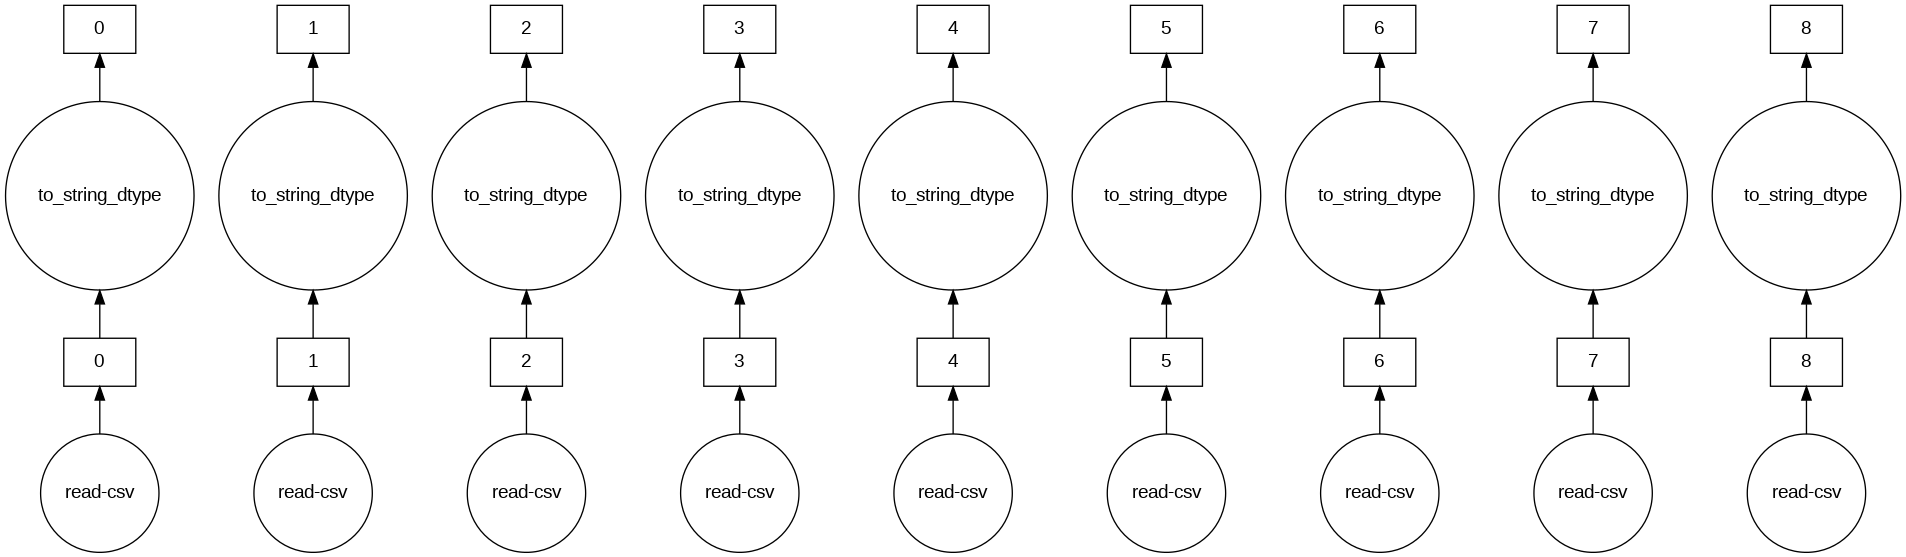

In [14]:
df_users.visualize(tasks=True)

In [15]:
# number of unique tracks in the data

unique_tracks = df_users.loc[:,"track_id"].nunique()
unique_tracks = unique_tracks.compute()

print(unique_tracks)

30459


In [16]:
# number of unique users in the data

unique_users = df_users.loc[:,"user_id"].nunique()
unique_users = unique_users.compute()
print(unique_tracks)

30459


In [17]:
# number of unique track_ids in the data

unique_track_ids = df_users.loc[:,"track_id"].unique().compute()

unique_track_ids = unique_track_ids.tolist()

In [18]:
len(unique_track_ids)

30459

In [19]:
# filtering songs from the songs dataset

filtered_songs = df_songs[df_songs['track_id'].isin(unique_track_ids)]
filtered_songs.reset_index(drop=True,inplace=True)

In [20]:
filtered_songs

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
3,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...
4,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...
...,...,...,...,...
30454,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...
30455,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...
30456,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...


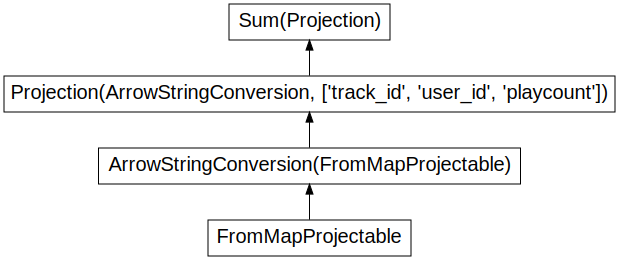

In [21]:
# group by 'track_id' and 'user_id' and compute their sum of 'playcount'

aggregated_df = df_users.groupby(['track_id','user_id'])['playcount'].sum()
aggregated_df.visualize()

### Creating Sparse Matrix

In [22]:
import numpy as np
from scipy.sparse import csr_matrix

In [23]:
# 1. Load the data with dask

df_users = dd.read_csv(users_data_path)

# 2. Ensure playcount is numeric and track_id, user_id categorized
df_users['playcount']=df_users['playcount'].astype(np.float64)
df_users = df_users.categorize(columns=['user_id','track_id'])

# 3. Convert user_id and track_id to numeric indices
track_mapping = df_users['track_id'].cat.codes
user_mapping = df_users['user_id'].cat.codes

# Adding the cat-code columns in the dataframe
df_users = df_users.assign(
    user_idx = user_mapping,
    track_idx = track_mapping
)

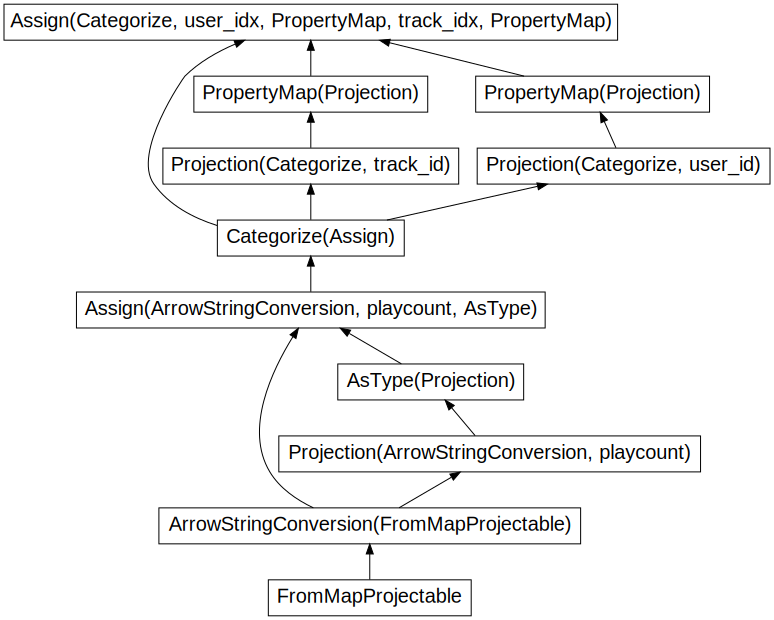

In [24]:
df_users.visualize()

In [25]:
# 4. Compute the interaction matrix
# Dask doesn't support pivot tables directly, so we aggregate manually

interaction_matrix = df_users.groupby(['track_idx','user_idx'])['playcount'].sum().reset_index()


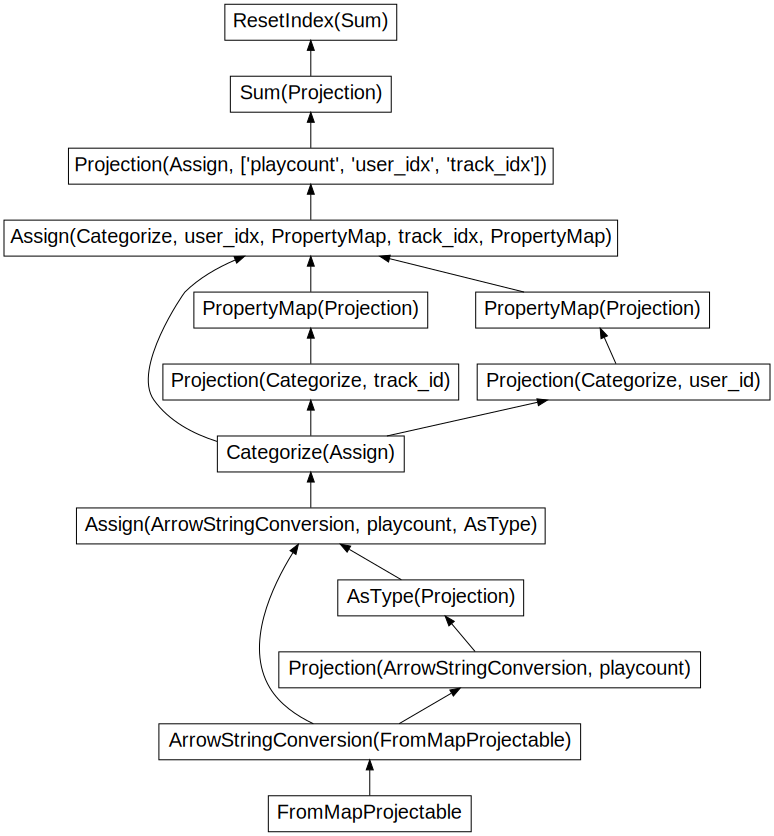

In [26]:
interaction_matrix.visualize()

In [27]:
interaction_matrix

,track_idx,user_idx,playcount
npartitions=1,,,
,int16,int32,float64
,...,...,...


In [28]:
interaction_matrix = interaction_matrix.compute()

In [29]:
interaction_matrix

,track_idx,user_idx,playcount
0,0,15780,3.0
1,0,76968,1.0
2,0,134525,2.0
3,0,231541,1.0
4,0,305348,1.0
...,...,...,...
9711296,30458,902360,1.0
9711297,30458,913310,1.0
9711298,30458,922319,1.0
9711299,30458,925779,1.0


In [30]:
interaction_matrix['playcount'].max()

2948.0

In [31]:
interaction_matrix[interaction_matrix['playcount'] == 2948]

,track_idx,user_idx,playcount
9452405,23423,90833,2948.0


In [32]:
# 5. Creating a sparse matrix
# collecting the data into numpy friendly format

row_indices = interaction_matrix['track_idx']
col_indices = interaction_matrix['user_idx']
values = interaction_matrix['playcount']

In [33]:
# build a sparse matrix

n_tracks = unique_tracks
n_users = unique_users

sparse_matrix = csr_matrix((values,(row_indices,col_indices)),shape=(n_tracks,n_users))

print("Sparse matrix shape : ", sparse_matrix.shape)
print("Non-zero elements : ",sparse_matrix.nnz)

Sparse matrix shape :  (30459, 962037)
Non-zero elements :  9711301


In [34]:
sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9711301 stored elements and shape (30459, 962037)>

In [35]:
(sparse_matrix.nnz/ (sparse_matrix.shape[0] * sparse_matrix.shape[1] )*100)

0.033141335019756815

In [36]:
sparse_matrix[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 161 stored elements and shape (1, 962037)>

In [37]:
np.where(df_users['track_id'].cat.categories=="TROINZB128F932F740")

(array([17018]),)

In [38]:
ind = 17018

In [39]:
input_vector = sparse_matrix[ind]
input_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 610 stored elements and shape (1, 962037)>

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

In [41]:
similarity_score = cosine_similarity(input_vector,sparse_matrix)

In [42]:
np.sort(similarity_score.ravel())[-5:]

array([0.05529279, 0.05592032, 0.07217127, 0.08225488, 1.        ])

In [43]:
similarity_score.shape

(1, 30459)

In [44]:
np.argsort(similarity_score.ravel())[-5:][::-1]

array([17018, 24529, 28964,  3620,  9470])

In [45]:
recommendations = df_users['track_id'].cat.categories[np.argsort(similarity_score.ravel())[-5:][::-1]]

In [46]:
recommendations

Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4'],
      dtype='string', name='track_id')

In [47]:
filtered_songs[filtered_songs['track_id'].isin(recommendations)].set_index('track_id').reindex(recommendations).reset_index()

,track_id,name,artist,spotify_preview_url
0,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
1,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
2,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
3,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
4,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...


In [48]:
# .isin doesn't care about the order it just checks if its available or not
# and returns data in indexed order
# so set index -> reindex(recommendation) -> reset index = your song data in order
filtered_songs_ordered = filtered_songs.set_index('track_id').reindex(recommendations).reset_index()
display(filtered_songs_ordered)

,track_id,name,artist,spotify_preview_url
0,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
1,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
2,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
3,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
4,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...


In [49]:
def collaborative_filtering(song_name,user_data,songs_data,sparse_matrix,k=5):
  # fetch the row from songs data
  song_row = songs_data[songs_data["name"]==song_name]
  print(song_row)

  # track_id of input song
  input_track_id = song_row['track_id'].values.item()
  print(input_track_id)

  # index value of track id
  ind = np.where(user_data['track_id'].cat.categories == input_track_id)[0].item()
  print(ind)

  # fetch the input vector
  input_vector = sparse_matrix[ind]

  # get similarity scores
  similarity_scores = cosine_similarity(input_vector,sparse_matrix)

  # get top k recommendation
  recommendation_track_ids = user_data['track_id'].cat.categories[np.argsort(similarity_score.ravel())[-k-1:][::-1]]
  print(recommendation_track_ids)

  # get top scores
  top_scores = np.sort(similarity_score.ravel())[-k-1:][::-1]
  print(top_scores)

  # get the songs from the data and print
  top_k_songs = (
                  songs_data[songs_data['track_id'].isin(recommendation_track_ids)]
                  .set_index('track_id')
                  .reindex(recommendation_track_ids)
                  .reset_index()
                  )

  return top_k_songs


In [50]:
collaborative_filtering("Crazy in Love",df_users,filtered_songs,sparse_matrix)

                track_id           name   artist  \
3337  TROINZB128F932F740  Crazy in Love  Beyoncé   

                                    spotify_preview_url  
3337  https://p.scdn.co/mp3-preview/807828ea7070bda7...  
TROINZB128F932F740
17018
Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26'],
      dtype='string', name='track_id')
[1.         0.08225488 0.07217127 0.05592032 0.05529279 0.05404559]


,track_id,name,artist,spotify_preview_url
0,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
1,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
2,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
3,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
4,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...
5,TRGEUXY128F4226B26,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...


## Using nearest neighbor

In [55]:
from sklearn.neighbors import NearestNeighbors

In [57]:
model = NearestNeighbors(metric='cosine',algorithm='brute')

In [58]:
model.fit(sparse_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [60]:
dist,index = model.kneighbors(input_vector)

In [66]:
recommendation = df_users['track_id'].cat.categories[index.ravel()]

In [69]:
filtered_songs[filtered_songs['track_id'].isin(recommendation)].set_index('track_id').reindex(recommendations).reset_index()

,track_id,name,artist,spotify_preview_url
0,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
1,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
2,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
3,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
4,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...
